 # Лабораторна робота 11

 ## Setup

In [ ]:
%pip install dlib-bin numpy scikit-image

import os

model_dir = "."

url_landmarks = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"
filename_landmarks = os.path.join(model_dir, "shape_predictor_68_face_landmarks.dat")

url_face_rec = "http://dlib.net/files/dlib_face_recognition_resnet_model_v1.dat.bz2"
filename_face_rec = os.path.join(model_dir, "dlib_face_recognition_resnet_model_v1.dat")

if not os.path.exists(filename_landmarks):
    print(f"Завантаження {os.path.basename(filename_landmarks)}.bz2...")
    !curl -L -o {filename_landmarks}.bz2 {url_landmarks}
    !bzip2 -dk {filename_landmarks}.bz2
    
if not os.path.exists(filename_face_rec):
    print(f"Завантаження {os.path.basename(filename_face_rec)}.bz2...")
    !curl -L -o {filename_face_rec}.bz2 {url_face_rec}
    !bzip2 -dk {filename_face_rec}.bz2
    
print("Підготовка завершена.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 15.4 MB/s eta 0:00:00a 0:00:01
Завантаження shape_predictor_68_face_landmarks.dat.bz2...
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   272  100   272    0     0   1685      0 --:--:-- --:--:-- --:--:--  1679
100 61.0M  100 61.0M    0     0  29.8M      0  0:00:02  0:00:02 --:--:-- 57.3M
Завантаження dlib_face_recognition_resnet_model_v1.dat.bz2...
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   276  100   276    0     0   1884      0 --:--:-- --:--:-- --:--:--  1890
100 20.4M  100 20.4M    0     0  12.9M      0  0:00:01  0:00:01 --:--:-- 21.3M
Підготовка завершена.


 ## Імпорт модулів та завантаження моделей

In [ ]:
import dlib
import numpy as np
from skimage import io
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt

# HOG-детектор
face_detector = dlib.get_frontal_face_detector()

# Визначення 68 ключових точок обличчя
shape_predictor = dlib.shape_predictor(filename_landmarks)

# Вилучення дескрипторів обличчя (128-D вектор)
face_recognizer = dlib.face_recognition_model_v1(filename_face_rec)

print("Модулі імпортовані та моделі завантажені.")


Модулі імпортовані та моделі завантажені.


## Завантаження тесових зображень

In [ ]:
image_filenames = ["photo1.png", "photo2.png"]
for i in image_filenames:
    !wget -nc https://raw.githubusercontent.com/oleksandr-holan/deep-learning/refs/heads/master/lab11/test_images/{i} -P ./uploaded_files

--2026-01-08 17:52:45--  https://raw.githubusercontent.com/oleksandr-holan/deep-learning/refs/heads/master/lab11/test_images/photo1.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1518687 (1.4M) [image/png]
Saving to: ‘./uploaded_files/photo1.png’

photo1.png          100%[===================>]   1.45M  --.-KB/s    in 0.03s   

2026-01-08 17:52:45 (44.5 MB/s) - ‘./uploaded_files/photo1.png’ saved [1518687/1518687]

--2026-01-08 17:52:45--  https://raw.githubusercontent.com/oleksandr-holan/deep-learning/refs/heads/master/lab11/test_images/photo2.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:44

In [18]:
!rm -rf ./uploaded_files/

Фотографія 1 завантажена.
Зображення конвертовано з RGBA у RGB.
Масив зображення зроблено C-неперервним.

Дескриптор обличчя 1 (перші 5 елементів):
[-0.15235487  0.18319339  0.06693476 -0.03186233 -0.07341971]
Знайдено облич: 1


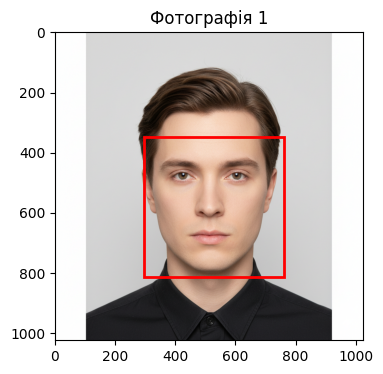

In [ ]:
# Завантаження першої фотографії
try:
    img1 = io.imread('./uploaded_files/photo1.png')
    print("Фотографія 1 завантажена.")
except FileNotFoundError:
    print("ПОМИЛКА: Файл 'photo1.png' не знайдено. Будь ласка, завантажте його.")
    exit(1)

# Модель працює тільки з трьома каналами
if img1.ndim == 3 and img1.shape[2] == 4:
    img1 = img1[:, :, :3]
    print("Зображення конвертовано з RGBA у RGB.")
# Модель працює тільки uint8 зображеннями   
if img1.dtype != np.uint8:
    img1 = img1.astype(np.uint8)
    print("Тип даних зображення конвертовано у np.uint8.") 
# Після конвертацій зʼявляються пусті комірки памʼяті у масиві зображень
# dlib вимагає, щоб масив був C-неперервним
if not img1.flags['C_CONTIGUOUS']:
    img1 = np.ascontiguousarray(img1)
    print("Масив зображення зроблено C-неперервним.")

detections1 = face_detector(img1, 1)

if len(detections1) == 0:
    print("Обличчя не знайдено на фотографії 1.")
    descriptor1 = None
else:
    face_rect1 = detections1[0]
    
    # Ключові точки
    shape1 = shape_predictor(img1, face_rect1)
    
    # 128-D вектор
    descriptor1 = face_recognizer.compute_face_descriptor(img1, shape1)
    
    print("\nДескриптор обличчя 1 (перші 5 елементів):")
    print(np.array(descriptor1)[:5])
    print(f"Знайдено облич: {len(detections1)}")
    
    plt.figure(figsize=(8, 4))
    plt.imshow(img1)
    plt.title("Фотографія 1")
    # Прямокутник навколо обличчя
    plt.gca().add_patch(plt.Rectangle((face_rect1.left(), face_rect1.top()), 
                                      face_rect1.width(), face_rect1.height(),
                                      edgecolor='r', facecolor='none', lw=2))
    plt.show()



 ## Обробка другого фото

Фотографія 2 завантажена.
Зображення конвертовано з RGBA у RGB.
Масив зображення зроблено C-неперервним.

Дескриптор обличчя 2 (перші 5 елементів):
[-0.11901634  0.12388569  0.06133417 -0.0276773  -0.04554731]
Знайдено облич: 1


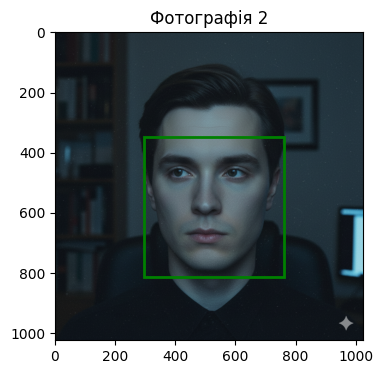

In [20]:
try:
    img2 = io.imread('./uploaded_files/photo2.png')
    print("Фотографія 2 завантажена.")
except FileNotFoundError:
    print("ПОМИЛКА: Файл 'photo2.png' не знайдено. Будь ласка, завантажте його.")
    exit(1)

if img2.ndim == 3 and img2.shape[2] == 4:
    img2 = img2[:, :, :3]
    print("Зображення конвертовано з RGBA у RGB.")

if img2.dtype != np.uint8:
    img2 = img2.astype(np.uint8)
    print("Тип даних зображення конвертовано у np.uint8.")

if not img2.flags["C_CONTIGUOUS"]:
    img2 = np.ascontiguousarray(img2)
    print("Масив зображення зроблено C-неперервним.")

detections2 = face_detector(img2, 1)

if len(detections2) == 0:
    print("Обличчя не знайдено на фотографії 2.")
    descriptor2 = None
else:
    face_rect2 = detections2[0]
    
    shape2 = shape_predictor(img2, face_rect2)
    
    descriptor2 = face_recognizer.compute_face_descriptor(img2, shape2)
    
    print("\nДескриптор обличчя 2 (перші 5 елементів):")
    print(np.array(descriptor2)[:5])
    print(f"Знайдено облич: {len(detections2)}")
    
    plt.figure(figsize=(8, 4))
    plt.imshow(img2)
    plt.title("Фотографія 2")
    plt.gca().add_patch(plt.Rectangle((face_rect2.left(), face_rect2.top()), 
                                      face_rect2.width(), face_rect2.height(),
                                      edgecolor='g', facecolor='none', lw=2))
    plt.show()


## Порівняння дескрипторів та верифікація

In [ ]:
if descriptor1 is not None and descriptor2 is not None:
    distance = euclidean(np.array(descriptor1), np.array(descriptor2))
    
    VERIFICATION_THRESHOLD = 0.6
    
    print("\n--- Результати Верифікації ---")
    print(f"Евклідова відстань між дескрипторами: {distance:.4f}")
    print(f"Поріг dlib для верифікації: {VERIFICATION_THRESHOLD}")
    
    if distance < VERIFICATION_THRESHOLD:
        print("ВЕРДИКТ: Відстань МЕНШЕ порогу. Ймовірно, на фотографіях ЗОБРАЖЕНА ОДНА ЛЮДИНА.")
    else:
        print("ВЕРДИКТ: Відстань БІЛЬШЕ порогу. Ймовірно, на фотографіях ЗОБРАЖЕНІ РІЗНІ ЛЮДИ.")
else:
    print("\nНеможливо провести порівняння, оскільки на одній або обох фотографіях не знайдено обличчя.")



--- Результати Верифікації ---
Евклідова відстань між дескрипторами: 0.3339
Поріг dlib для верифікації: 0.6
ВЕРДИКТ: Відстань МЕНШЕ порогу. Ймовірно, на фотографіях ЗОБРАЖЕНА ОДНА ЛЮДИНА.


 ## Експериментальні дослідження

In [ ]:
image_filenames = ["boy1.png", "boy2.png", "girl1.png", "man1.png", "margot_robbie1.jpg", "margot_robbie2.webp", "margot_robbie3.webp", "twin1.webp", "twin2.webp"]
for i in image_filenames:
    !wget -nc https://raw.githubusercontent.com/oleksandr-holan/deep-learning/refs/heads/master/lab11/test_images/{i} -P ./uploaded_files


 ## 6. Експериментальні дослідження



 Завантажимо додаткові тестові зображення та проведемо серію експериментів для перевірки стійкості алгоритму.

In [ ]:
import os

image_filenames = [
    "boy1.png",
    "boy2.png",  # Різні хлопці
    "girl1.png",  # Інша людина (дівчинка)
    "man1.png",  # Інша людина (чоловік)
    "margot_robbie1.jpg",  # Марго Роббі
    "margot_robbie2.webp",  # Марго Роббі
    "margot_robbie3.webp",  # Марго Роббі
    "twin1.webp",
    "twin2.webp",  # Схожі, але різні люди
    "me1.jpg",
    "me2.jpg",
    "me3.jpg",
    "me4.jpg",
    "me5.jpg",
    "me6.jpg",
    "me7.jpg",
    "me8.jpg",
    "me9.jpg",
    "me10.jpg",
    "me11.jpg",
    "me12.jpg",
    "me13.jpg",
    "me14.jpg",
    "me15.jpg"
]

save_dir = "./uploaded_files"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

print("Завантаження файлів...")
for i in image_filenames:
    url = f"https://raw.githubusercontent.com/oleksandr-holan/deep-learning/refs/heads/master/lab11/test_images/{i}"
    !wget -q --show-progress -nc {url} -P {save_dir}

print("Завантаження завершено.")


Завантаження файлів...
me13.jpg            100%[===================>] 161.65K  --.-KB/s    in 0.01s   
me14.jpg            100%[===================>] 176.06K  --.-KB/s    in 0.01s   
me15.jpg            100%[===================>] 149.14K  --.-KB/s    in 0.01s   
Завантаження завершено.


 ### Функція для автоматичного порівняння

In [ ]:
def get_face_data(filepath):
    """Завантажує зображення та повертає (img, descriptor, face_rect)"""
    try:
        img = io.imread(filepath)
    except Exception as e:
        print(f"Помилка читання файлу {filepath}: {e}")
        return None, None, None

    if img.ndim == 3 and img.shape[2] == 4:
        img = img[:, :, :3]
    if img.dtype != np.uint8:
        img = img.astype(np.uint8)
    if not img.flags['C_CONTIGUOUS']:
        img = np.ascontiguousarray(img)

    detections = face_detector(img, 1)
    
    if not detections:
        return img, None, None
    
    face_rect = detections[0]
    shape = shape_predictor(img, face_rect)
    descriptor = face_recognizer.compute_face_descriptor(img, shape)
    
    return img, np.array(descriptor), face_rect

def compare_images(file1, file2, title_text="Порівняння"):
    path1 = os.path.join("./uploaded_files", file1)
    path2 = os.path.join("./uploaded_files", file2)
    
    img1, desc1, rect1 = get_face_data(path1)
    img2, desc2, rect2 = get_face_data(path2)
    
    if desc2 is None:
        print(f"ПОМИЛКА: Не вдалося знайти обличчя на зображенні {file2}.")
        return
    if desc1 is None:
        print(f"ПОМИЛКА: Не вдалося знайти обличчя на зображенні {file1}.")
        return


    distance = euclidean(desc1, desc2)
    threshold = 0.6
    is_same = distance < threshold
    
    # Візуалізація
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Фото 1
    axes[0].imshow(img1)
    axes[0].set_title(file1)
    if rect1:
        rect = plt.Rectangle((rect1.left(), rect1.top()), rect1.width(), rect1.height(),
                             edgecolor='blue', facecolor='none', lw=2)
        axes[0].add_patch(rect)
    axes[0].axis('off')

    # Фото 2
    axes[1].imshow(img2)
    axes[1].set_title(file2)
    if rect2:
        rect = plt.Rectangle((rect2.left(), rect2.top()), rect2.width(), rect2.height(),
                             edgecolor='blue', facecolor='none', lw=2)
        axes[1].add_patch(rect)
    axes[1].axis('off')
    
    verdict_color = "green" if is_same else "red"
    verdict_text = "ОДНА ЛЮДИНА" if is_same else "РІЗНІ ЛЮДИ"
    
    plt.suptitle(f"{title_text}\nВідстань: {distance:.4f} (Поріг: {threshold})\nВердикт: {verdict_text}", 
                 fontsize=14, color=verdict_color, y=1.05)
    plt.tight_layout()
    plt.show()


 ### Експеримент 1: Різні люди

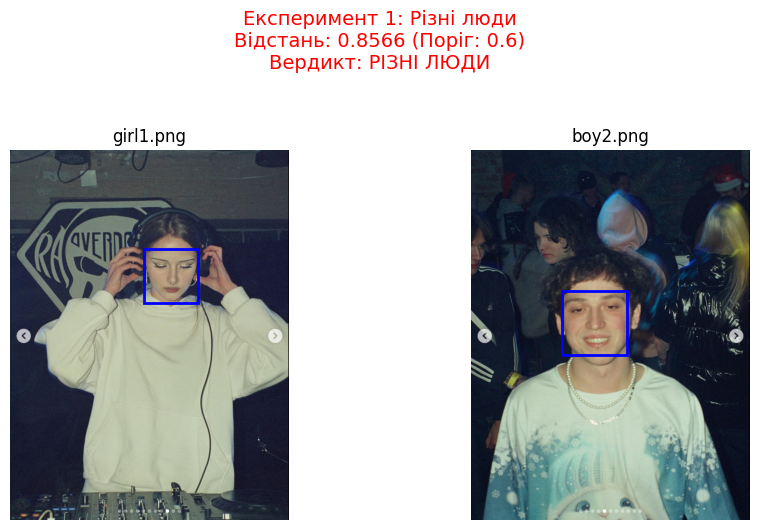

In [ ]:
compare_images("girl1.png", "boy2.png", title_text="Експеримент 1: Різні люди")

# compare_images("man1.png", "boy1.png", title_text="Експеримент 1: Різні статі/вік") # man1, boy1 are not recognized

 ### Експеримент 2: Дуже схожі люди

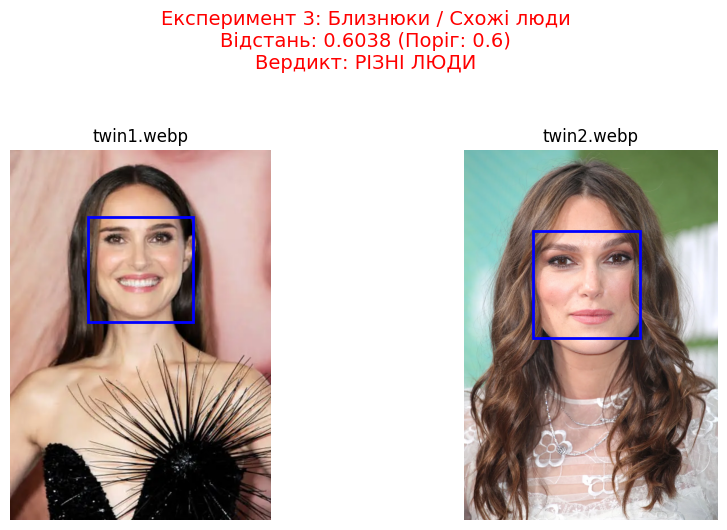

In [ ]:
compare_images("twin1.webp", "twin2.webp", title_text="Експеримент 2: Схожі люди")


 ### Експеримент 3: Вплив ракурсу та стилю (Марго Роббі)

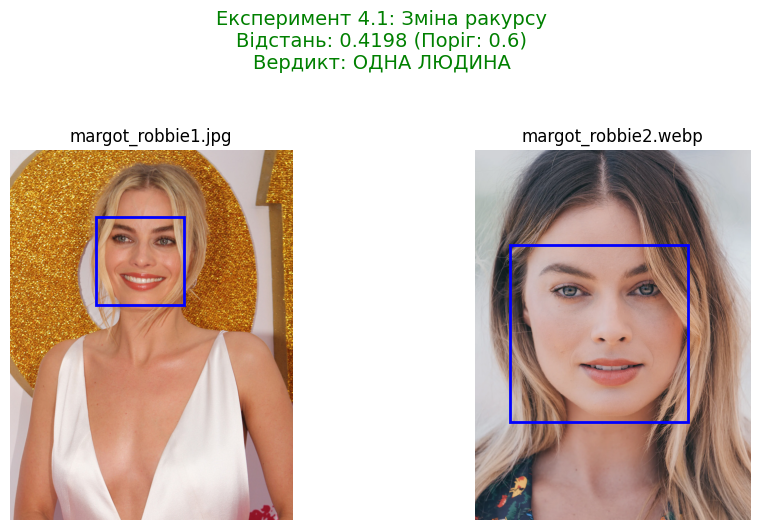

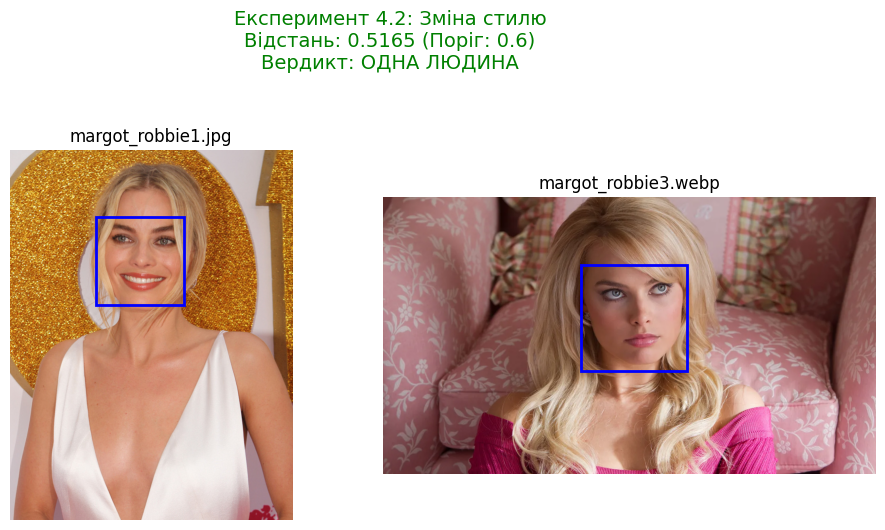

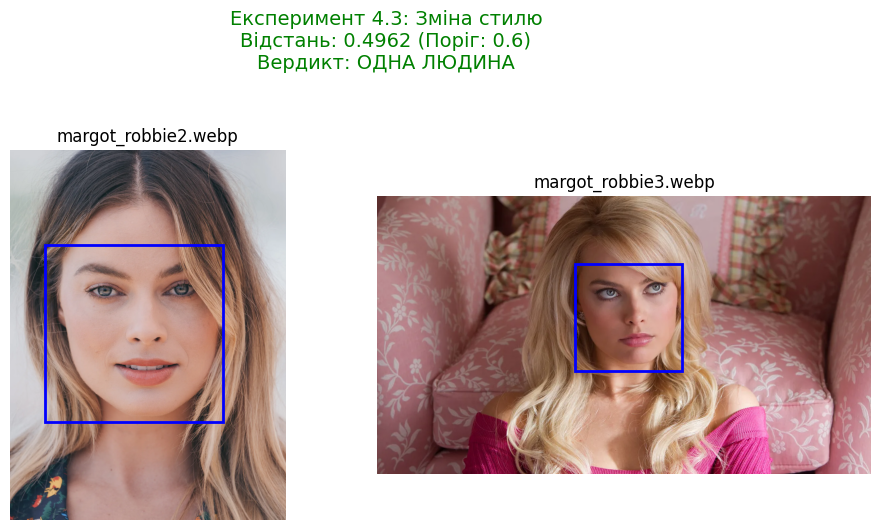

In [ ]:
compare_images("margot_robbie1.jpg", "margot_robbie2.webp", title_text="Експеримент 3.1: Зміна ракурсу")

compare_images("margot_robbie1.jpg", "margot_robbie3.webp", title_text="Експеримент 3.2: Зміна стилю")

compare_images(
    "margot_robbie2.webp",
    "margot_robbie3.webp",
    title_text="Експеримент 3.3: Зміна стилю",
)

### Експеримент 4: Мої фото

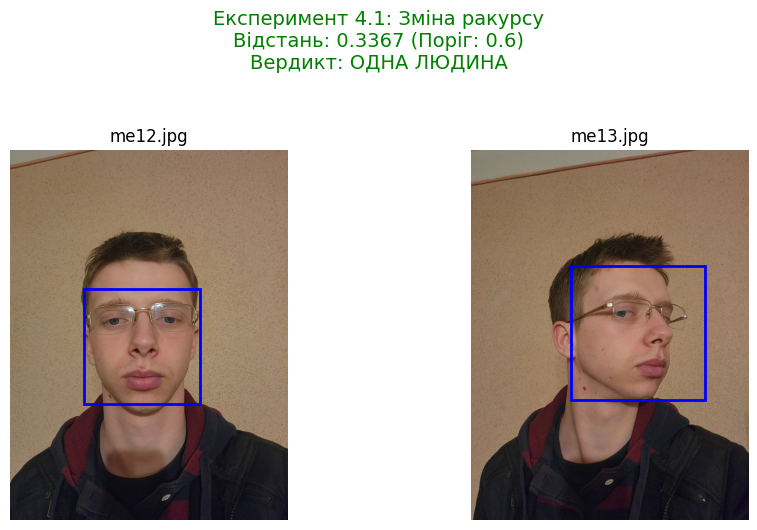

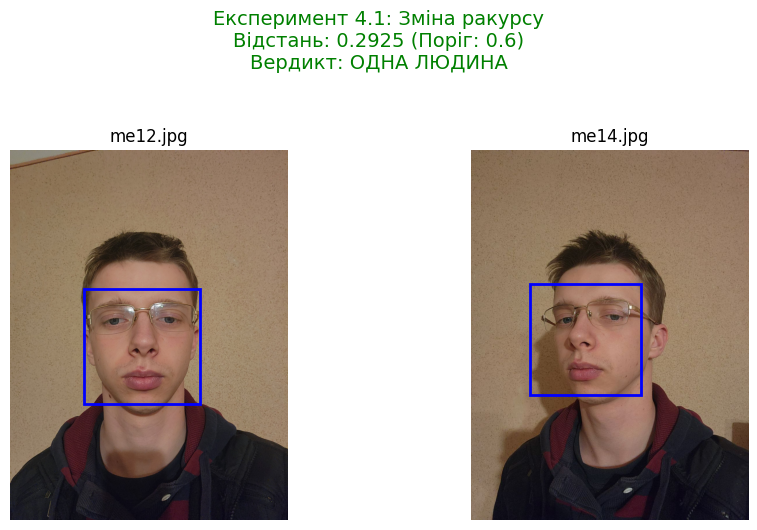

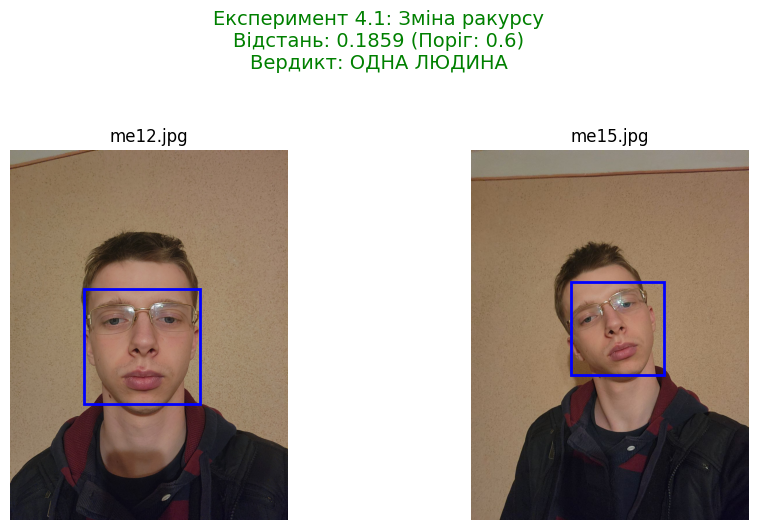

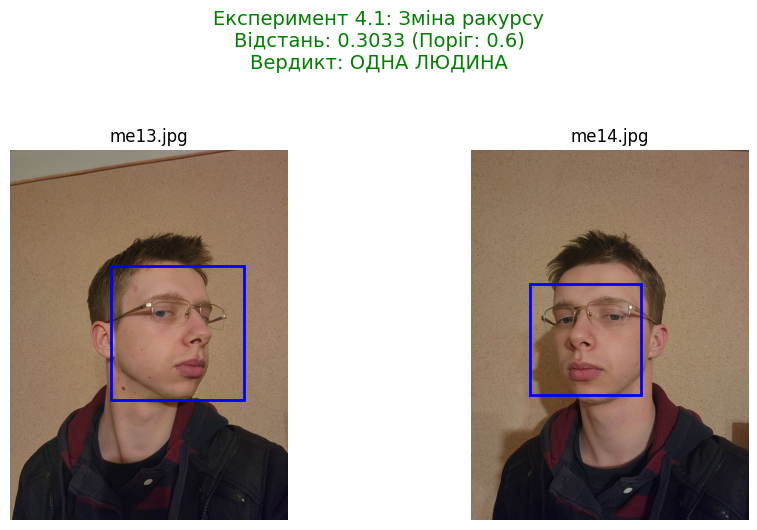

In [ ]:
compare_images(
    "me12.jpg",
    "me13.jpg",
    title_text="Експеримент 4.1: Зміна ракурсу",
)

compare_images(
    "me12.jpg",
    "me14.jpg",
    title_text="Експеримент 4.2: Зміна ракурсу",
)

compare_images(
    "me12.jpg",
    "me15.jpg",
    title_text="Експеримент 4.3: Зміна ракурсу",
)

compare_images(
    "me13.jpg",
    "me14.jpg",
    title_text="Експеримент 4.4: Зміна ракурсу",
)


## Deepface

In [ ]:
%pip install deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.8 MB/s eta 0:00:00


In [63]:
# %%
from deepface import DeepFace
import matplotlib.pyplot as plt
import cv2
import os


def compare_images_openface_model(
    file1, file2, title_text="Порівняння (Model: OpenFace)"
):
    """
    Порівнює два зображення, використовуючи архітектуру OpenFace через бібліотеку DeepFace.
    """
    path1 = os.path.join("./uploaded_files", file1)
    path2 = os.path.join("./uploaded_files", file2)

    # Перевірка існування файлів
    if not os.path.exists(path1) or not os.path.exists(path2):
        print("Помилка: Один з файлів не знайдено.")
        return

    print(f"Обробка {file1} та {file2} за допомогою OpenFace...")

    try:
        # DeepFace.verify виконує весь pipeline:
        # Detect -> Align -> Represent (OpenFace) -> Verify
        # model_name="OpenFace" вмикає саме ту нейромережу, яку вимагає завдання.
        result = DeepFace.verify(
            img1_path=path1,
            img2_path=path2,
            model_name="OpenFace",
            detector_backend="dlib",  # possible options: "opencv", "dlib", "retinaface"
            enforce_detection=False,  # Не падати з помилкою, якщо обличчя нечітке
        )
    except Exception as e:
        print(f"Помилка при обробці deepface: {e}")
        return

    # Отримання результатів
    distance = result["distance"]
    threshold = result["threshold"]
    verified = result["verified"]  # True або False

    # --- Візуалізація ---
    # Завантажуємо зображення для відображення (конвертуємо BGR -> RGB для matplotlib)
    img1_show = cv2.cvtColor(cv2.imread(path1), cv2.COLOR_BGR2RGB)
    img2_show = cv2.cvtColor(cv2.imread(path2), cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img1_show)
    axes[0].set_title(file1)
    axes[0].axis("off")

    axes[1].imshow(img2_show)
    axes[1].set_title(file2)
    axes[1].axis("off")

    verdict_color = "green" if verified else "red"
    verdict_text = "ОДНА ЛЮДИНА" if verified else "РІЗНІ ЛЮДИ"

    plt.suptitle(
        f"{title_text}\nВідстань (Cosine/Euclidean): {distance:.4f} (Поріг: {threshold})\nВердикт: {verdict_text}",
        fontsize=14,
        color=verdict_color,
        y=1.05,
    )
    plt.tight_layout()
    plt.show()




 ### Експеримент 1: Різні люди

 Порівняємо чоловіка (`man1`) з дівчинкою (`girl1`). Очікуємо відстань > 0.6.

Обробка girl1.png та boy2.png за допомогою OpenFace...
26-01-08 19:27:57 - 🔗 openface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/openface_weights.h5 to /root/.deepface/weights/openface_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/openface_weights.h5
To: /root/.deepface/weights/openface_weights.h5
100%|██████████| 15.3M/15.3M [00:00<00:00, 99.5MB/s]


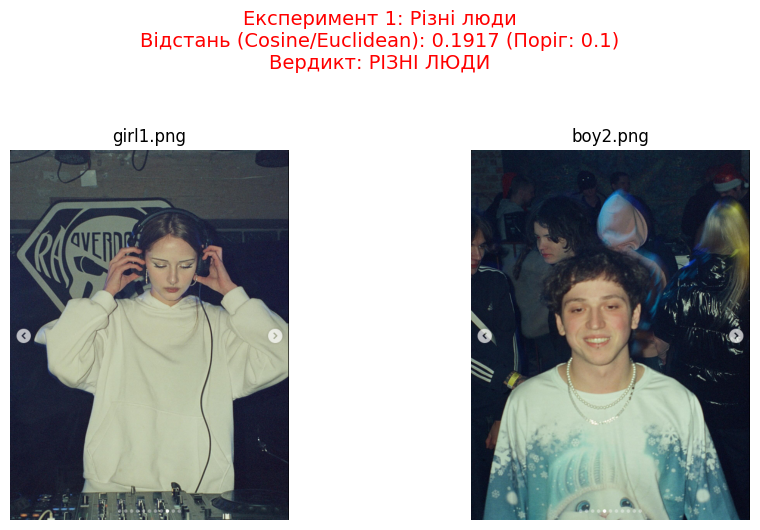

In [55]:
compare_images_openface_model(
    "girl1.png", "boy2.png", title_text="Експеримент 1: Різні люди"
)

# compare_images("man1.png", "girl1.png", title_text="Експеримент 2.2: Різні статі/вік")

 ### Експеримент 2: Дуже схожі люди

Обробка twin1.webp та twin2.webp за допомогою OpenFace...


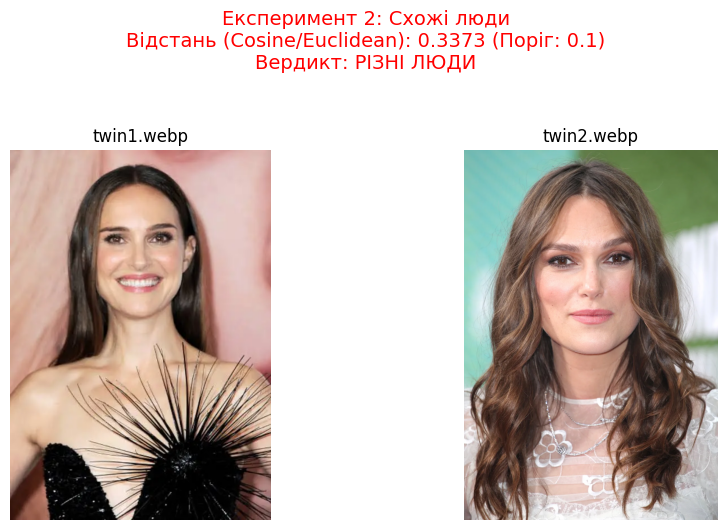

In [56]:
compare_images_openface_model(
    "twin1.webp", "twin2.webp", title_text="Експеримент 2: Схожі люди"
)


 ### Експеримент 3: Вплив ракурсу та стилю (Марго Роббі)

Обробка margot_robbie1.jpg та margot_robbie2.webp за допомогою OpenFace...


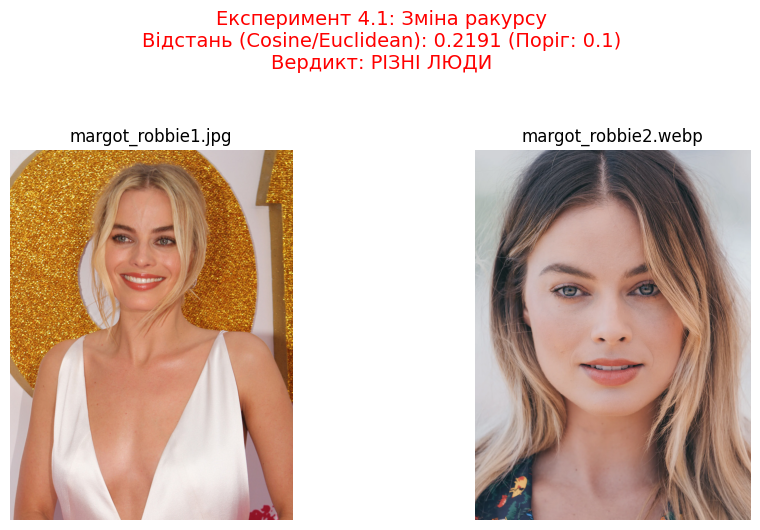

Обробка margot_robbie1.jpg та margot_robbie3.webp за допомогою OpenFace...


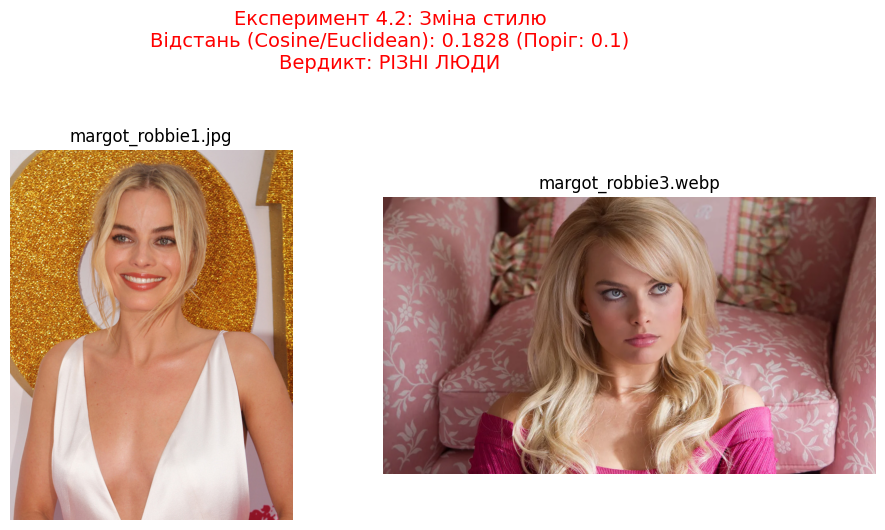

Обробка margot_robbie2.webp та margot_robbie3.webp за допомогою OpenFace...


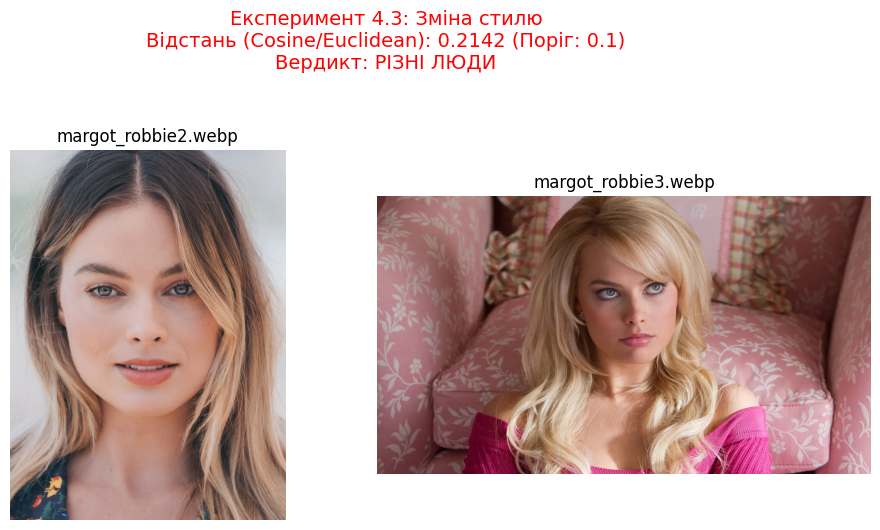

In [57]:
# Порівняння 1 та 2 (різні ракурси)
compare_images_openface_model(
    "margot_robbie1.jpg",
    "margot_robbie2.webp",
    title_text="Експеримент 4.1: Зміна ракурсу",
)

# Порівняння 1 та 3 (зміна стилю/емоції)
compare_images_openface_model(
    "margot_robbie1.jpg",
    "margot_robbie3.webp",
    title_text="Експеримент 4.2: Зміна стилю",
)

compare_images_openface_model(
    "margot_robbie2.webp",
    "margot_robbie3.webp",
    title_text="Експеримент 4.3: Зміна стилю",
)

### Експеримент 4: Мої фото

Обробка me12.jpg та me13.jpg за допомогою OpenFace...


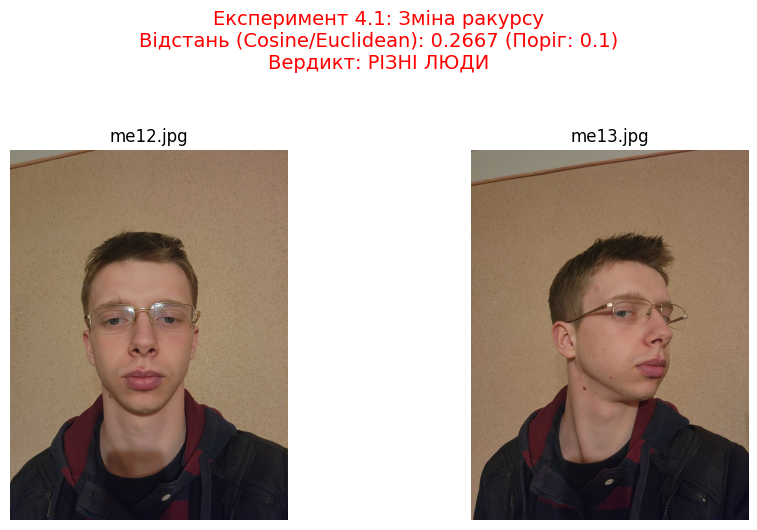

Обробка me12.jpg та me14.jpg за допомогою OpenFace...


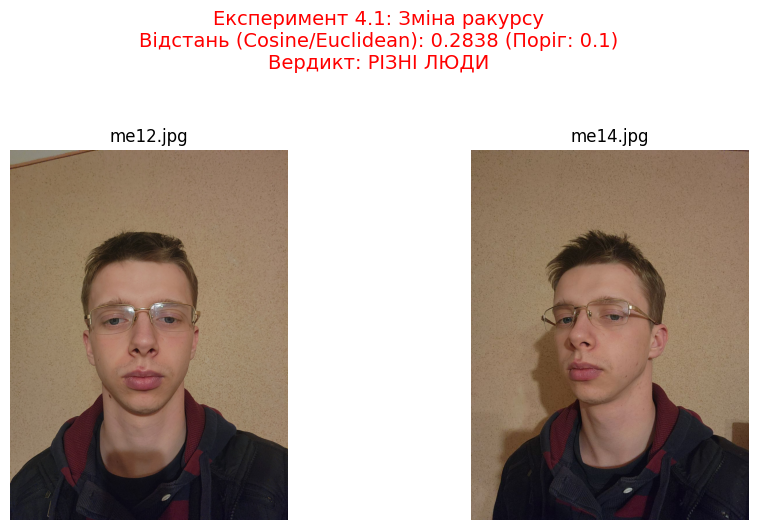

Обробка me12.jpg та me15.jpg за допомогою OpenFace...


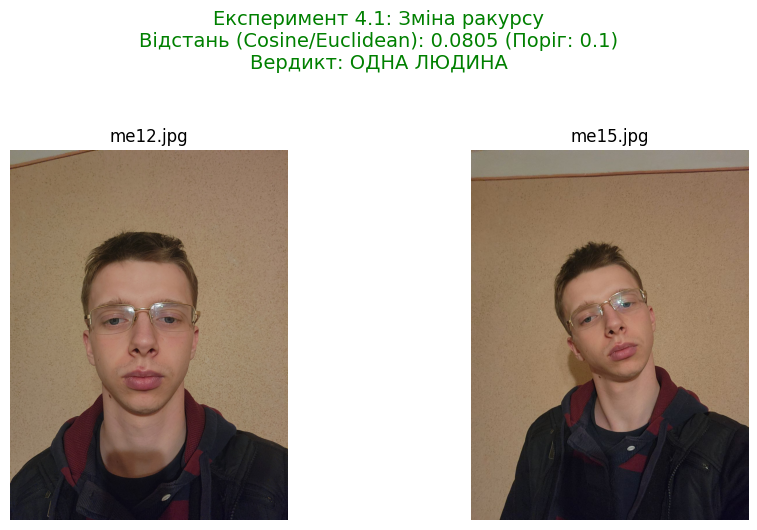

Обробка me13.jpg та me14.jpg за допомогою OpenFace...


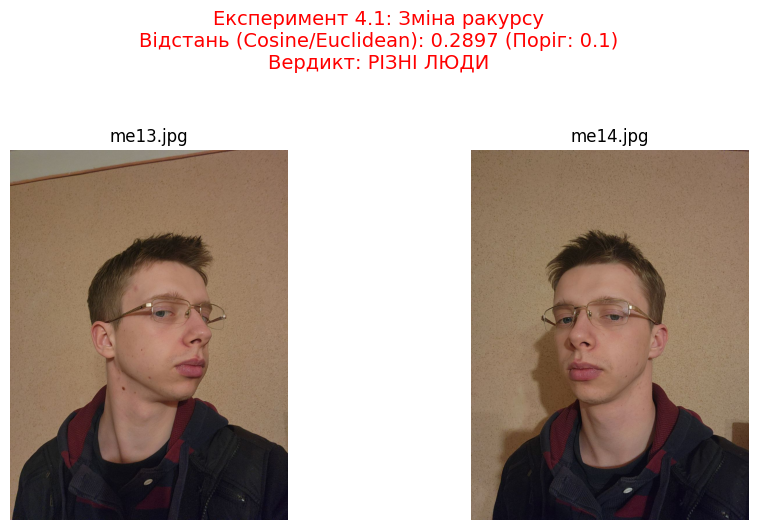

In [64]:
compare_images_openface_model(
    "me12.jpg",
    "me13.jpg",
    title_text="Експеримент 4.1: Зміна ракурсу",
)

compare_images_openface_model(
    "me12.jpg",
    "me14.jpg",
    title_text="Експеримент 4.1: Зміна ракурсу",
)

compare_images_openface_model(
    "me12.jpg",
    "me15.jpg",
    title_text="Експеримент 4.1: Зміна ракурсу",
)

compare_images_openface_model(
    "me13.jpg",
    "me14.jpg",
    title_text="Експеримент 4.1: Зміна ракурсу",
)
